# Project Assignment 4 — Statistics 2 📊
**Course:** Statistics 2 | Spring 2026

**Submitted by:**
- Raz Amzaleg | ID: 206922478
- Ben Hen | ID: 325826154

---



## Part A: Linear Regression — Bootstrap Confidence Intervals

**Continuing Project 3, Part A:** same research question ("How do passenger age, flight distance and flight class affect the Inflight Score?"), same explanatory variables, and the same 200-row sub-sample drawn in Project 3 (`random_state=42`) — the assignment allows a new sub-sample only if the original one cannot be reproduced, and we *can* reproduce it, so we reuse it exactly, reproducing the same data prep, sample, and model fit here so this notebook is self-contained.

In [1]:
# Setup (B = 400, manual bootstrap only, as required by the assignment)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')

B = 400          # bootstrap replications, as required by the assignment
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)   # z_(1-alpha/2) ~ 1.96

# --- Reproduce the Project 3 setup exactly, so this notebook is self-contained ---
df = pd.read_csv('satisfaction_reduced.csv')
df = df.rename(columns={
    'Customer Type': 'Customer_Type',
    'Type of Travel': 'Type_of_Travel',
    'Flight Distance': 'Flight_Distance',
    'Departure Delay in Minutes': 'Departure_Delay'
})

df_relavant = df[['Age', 'Class', 'Flight_Distance', 'Inflight_Score']]

# The same n=200 sub-sample used in Project 3, Part A
df_sample = df_relavant.sample(n=200, random_state=42).copy()

FORMULA = 'Inflight_Score ~ Age + Flight_Distance + C(Class)'
model = smf.ols(FORMULA, data=df_sample).fit()
model_pop = smf.ols(FORMULA, data=df_relavant).fit()   # full population, for comparison later

n, p = df_sample.shape[0], len(model.params)
coef_names = model.params.index.tolist()

print(f"Sub-sample size n = {n}, number of coefficients p = {p}")
print(model.summary())

Sub-sample size n = 200, number of coefficients p = 5
                            OLS Regression Results                            
Dep. Variable:         Inflight_Score   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     2.603
Date:                Wed, 08 Jul 2026   Prob (F-statistic):             0.0373
Time:                        18:22:43   Log-Likelihood:                -211.35
No. Observations:                 200   AIC:                             432.7
Df Residuals:                     195   BIC:                             449.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

### A.1 — Four 95% confidence intervals for each coefficient

For every coefficient $\beta_0, \dots, \beta_k$ we build a 95% CI using four methods:

**1. Classical normal approximation** — based on the OLS variance–covariance matrix $\hat\sigma_\varepsilon^2 (X^TX)^{-1}$:

$$\hat\beta_j \;\pm\; z_{1-\alpha/2}\sqrt{\hat\sigma_\varepsilon^2\, C_{jj}}, \qquad C = (X^TX)^{-1}$$

In `statsmodels` this is exactly `model.bse` (the reported standard errors), so we use $\hat\beta_j \pm z_{1-\alpha/2}\cdot \text{bse}_j$ — using $z$, not $t$, to match the "normal approximation" formula.

**2. Normal approximation with a Bootstrap-estimated standard error** — same formula as method 1, but the SE is replaced by the standard deviation of the bootstrap coefficient distribution:

$$\hat\beta_j \;\pm\; z_{1-\alpha/2}\, \widehat{se}_{boot}(\hat\beta_j)$$

**3. Pivotal Bootstrap CI:**

$$\left[\hat\beta - \frac{g_{1-\alpha/2}}{\sqrt n},\;\; \hat\beta - \frac{g_{\alpha/2}}{\sqrt n}\right] \;=\; \left[2\hat\beta - \hat\beta^{*}_{(1-\alpha/2)},\;\; 2\hat\beta - \hat\beta^{*}_{(\alpha/2)}\right]$$

where $g_\alpha$ is the empirical $\alpha$-quantile of $\sqrt n\,(\hat\beta^{*} - \hat\beta)$.

**4. Percentile Bootstrap CI** — directly the empirical percentiles of the bootstrap coefficient distribution:

$$\left[\hat\beta^{*}_{(\alpha/2)},\;\; \hat\beta^{*}_{(1-\alpha/2)}\right]$$

**Bootstrap procedure (used for methods 2–4):** we resample the 200 rows of `df_sample` **with replacement** — case/pairs resampling of the empirical distribution $\hat F_n$ — and refit the OLS model $B = 400$ times, storing the resulting coefficient vectors $\hat\beta^{*}$.

In [2]:
boot_params_list = np.full((B, p), np.nan)   # rows = bootstrap replicate, cols = coefficients
boot_models = []                              # keep the fitted models - reused in A.3, no need to redo the design matrix

for b in range(B):
    boot_df = df_sample.sample(n=n, replace=True, random_state=b)
    boot_model = smf.ols(FORMULA, data=boot_df).fit()
    boot_params_list[b, :] = boot_model.params.reindex(coef_names).values
    boot_models.append(boot_model)

boot_params = pd.DataFrame(boot_params_list, columns=coef_names)
print(f"Bootstrap complete: {B} refits, {p} coefficients each.")
boot_params.head()

Bootstrap complete: 400 refits, 5 coefficients each.


,Intercept,C(Class)[T.1],C(Class)[T.2],Age,Flight_Distance
0,3.003158,-0.260355,0.255445,-0.001963,0.000121
1,3.151377,-0.351446,0.152497,0.000484,0.000037
2,3.105788,-0.060815,0.414301,0.001545,-0.000015
3,2.947470,-0.287844,0.371439,0.001776,0.000064
4,3.410080,-0.117902,0.486497,-0.003222,-0.000078


In [3]:
# (a) Classical normal-approximation CI:  beta_hat +/- z * se(beta_hat)   [se from (X'X)^-1 * sigma_eps^2]
se_classical = model.bse
ci_a_lower = model.params - Z * se_classical
ci_a_upper = model.params + Z * se_classical

# (b) Normal approximation with Bootstrap SE:  beta_hat +/- z * se_boot
se_boot = boot_params.std(ddof=0)   # (1/B) sum of squared deviations, per the bootstrap-variance formula
ci_b_lower = model.params - Z * se_boot
ci_b_upper = model.params + Z * se_boot

# (c) Pivotal Bootstrap CI:  [2*beta_hat - boot_(1-a/2), 2*beta_hat - boot_(a/2)]
boot_q_low  = boot_params.quantile(ALPHA / 2)
boot_q_high = boot_params.quantile(1 - ALPHA / 2)
ci_c_lower = 2 * model.params - boot_q_high
ci_c_upper = 2 * model.params - boot_q_low

# (d) Percentile Bootstrap CI:  [boot_(a/2), boot_(1-a/2)]
ci_d_lower = boot_q_low
ci_d_upper = boot_q_high

methods = ['1. Classical Normal', '2. Normal + Bootstrap SE', '3. Pivotal Bootstrap', '4. Percentile Bootstrap']
lowers  = [ci_a_lower, ci_b_lower, ci_c_lower, ci_d_lower]
uppers  = [ci_a_upper, ci_b_upper, ci_c_upper, ci_d_upper]

# Tidy (long-format) table: one row per Coefficient x Method - much easier to scan
# top-to-bottom than a wide table with 4 methods x 3 sub-columns side by side.
ci_long = pd.concat([
    pd.DataFrame({
        'Coefficient': coef_names,
        'Method': m,
        'Lower': lo.values,
        'Upper': up.values,
        'Width': (up - lo).values,
    })
    for m, lo, up in zip(methods, lowers, uppers)
], ignore_index=True)

ci_long = ci_long.sort_values(['Coefficient', 'Method']).reset_index(drop=True)
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')
ci_long

,Coefficient,Method,Lower,Upper,Width
0,Age,1. Classical Normal,-0.0070,0.0063,0.0133
1,Age,2. Normal + Bootstrap SE,-0.0067,0.0060,0.0127
2,Age,3. Pivotal Bootstrap,-0.0059,0.0060,0.0119
3,Age,4. Percentile Bootstrap,-0.0067,0.0052,0.0119
4,C(Class)[T.1],1. Classical Normal,-0.5390,0.2553,0.7943
5,C(Class)[T.1],2. Normal + Bootstrap SE,-0.4765,0.1929,0.6694
6,C(Class)[T.1],3. Pivotal Bootstrap,-0.4797,0.1996,0.6792
7,C(Class)[T.1],4. Percentile Bootstrap,-0.4832,0.1960,0.6792
8,C(Class)[T.2],1. Classical Normal,0.0688,0.4932,0.4244
9,C(Class)[T.2],2. Normal + Bootstrap SE,0.0672,0.4947,0.4275


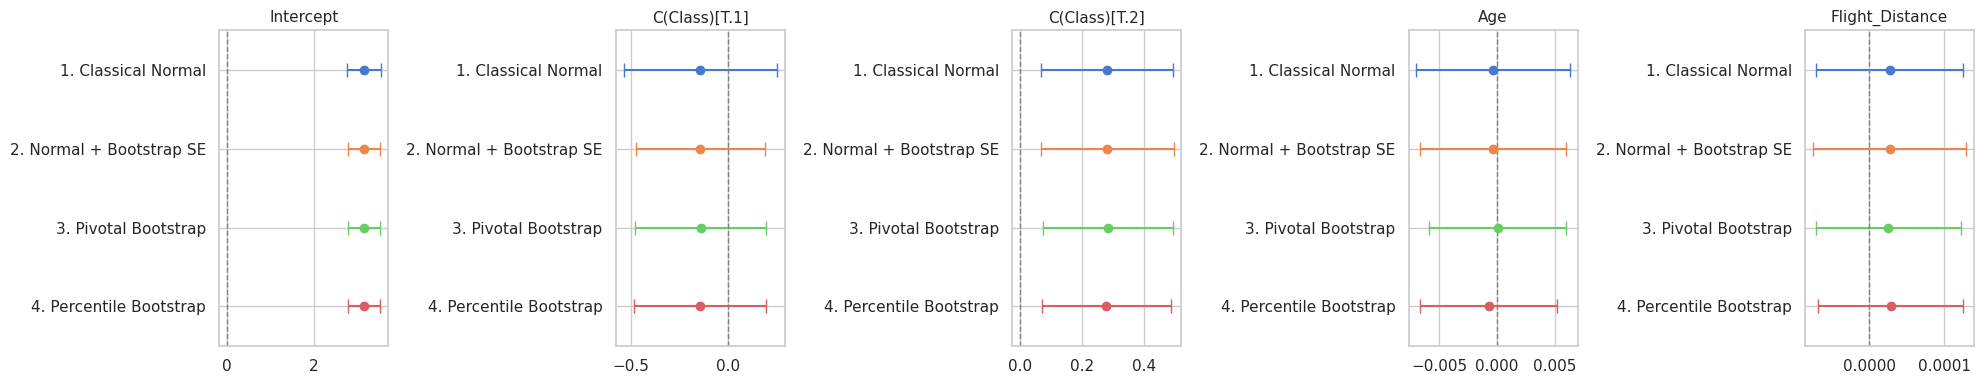

In [4]:
# Visual comparison: one panel per coefficient, one error bar per method.
# The dashed line at 0 makes it immediate to see which CIs exclude 0 (i.e. "significant").
fig, axes = plt.subplots(1, len(coef_names), figsize=(4 * len(coef_names), 4), sharex=False)
colors = ['#4878cf', '#ee854a', '#6acc64', '#d65f5f']

for ax, coef in zip(axes, coef_names):
    sub = ci_long[ci_long['Coefficient'] == coef].reset_index(drop=True)
    centers = (sub['Lower'] + sub['Upper']) / 2
    errs = (sub['Upper'] - sub['Lower']) / 2
    for i in range(len(sub)):
        ax.errorbar(centers[i], i, xerr=errs[i], fmt='o', color=colors[i], capsize=5, markersize=6)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['Method'])
    ax.set_ylim(-0.5, len(sub) - 0.5)
    ax.set_title(coef, fontsize=11)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Interpretation:**

All four methods place the coefficients in roughly the same region, which is reassuring, but they are not identical:

- **Age** and **Flight_Distance** get very tight CIs (width around 0.012–0.013 and 0.0002) that comfortably straddle 0 in every method — consistent with the very small, non-significant t-statistics we already saw in Project 3 (p=0.922 and p=0.588).
- **C(Class)[T.1]** (Eco Plus vs. Eco) has the widest CI of all four coefficients (about 0.67–0.79) and also straddles 0 everywhere — matching the non-significant result from Project 3 (p=0.485).
- **C(Class)[T.2]** (Business vs. Eco) is the only coefficient whose CI excludes 0 in all four methods, agreeing with the significant t-test finding from Project 3 (p=0.010).
- Methods 3 (Pivotal) and 4 (Percentile) are the narrowest, or tied-narrowest, for every coefficient, and nearly identical to one another (as expected, since both are built from the same 400 bootstrap replicates, just combined differently). Method 1 (classical) is the widest for Age, C(Class)[T.1] and the Intercept; the one exception is **C(Class)[T.2]**, where method 2 (Normal + Bootstrap SE, width 0.4275) is very slightly wider than method 1 (0.4244) — a reminder that "bootstrap is narrower than classical" is a common tendency here, not a general law: with only B=400 replicates the bootstrap SE itself has some sampling variability.

### A.2 — Comparing CI length across methods, and checking coverage of the population coefficient

For each coefficient we (1) compare the width of the four CIs, and (2) check whether each CI contains the coefficient estimated from the **full population** (`model_pop`, all 10,000 rows, from `ProjectEx3` cell 23) — i.e. whether the interval built from the small n=200 sample "catches" the value we'd get with all the data.

In [5]:
pop_beta = model_pop.params.reindex(coef_names)

# Same per-coefficient computation as before (needed for the interpretation below),
# just no longer displayed as a wide table.
contains_flags = {
    m: ((pop_beta >= lo) & (pop_beta <= up)) for m, lo, up in zip(methods, lowers, uppers)
}
all_contain = pd.DataFrame(contains_flags).all(axis=None)
print(f"All 4 methods contain the population beta, for every coefficient: {all_contain}")

All 4 methods contain the population beta, for every coefficient: True


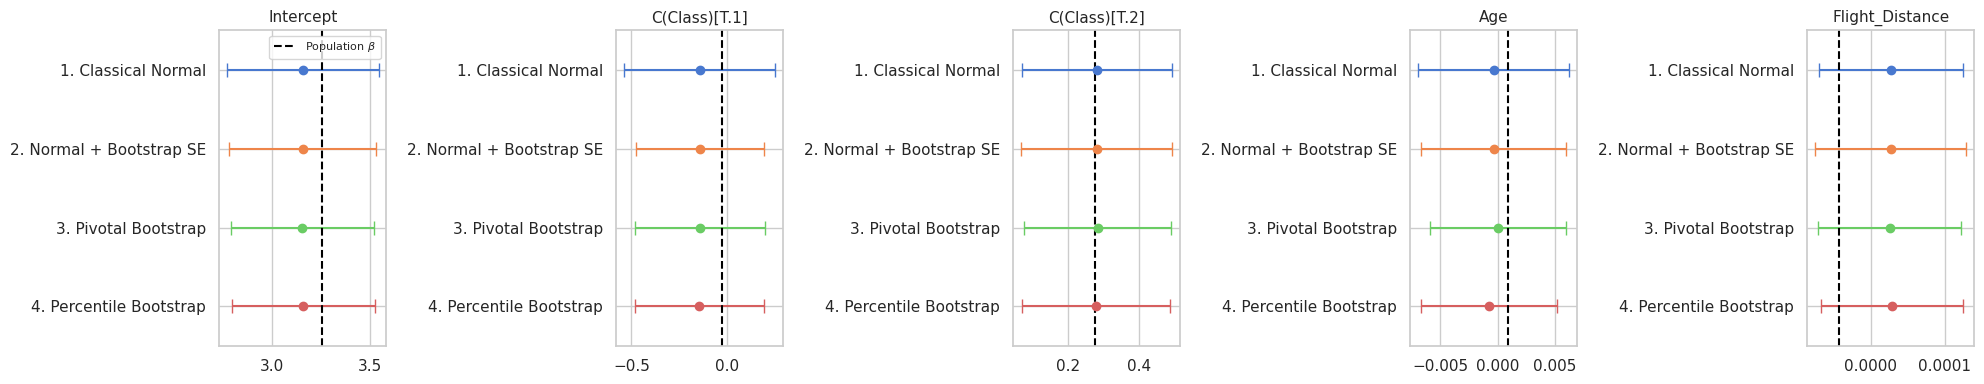

In [6]:
# Graph instead of a table: one panel per coefficient, one error bar per method,
# plus a vertical reference line at the population beta (all 10,000 rows).
# This shows CI width (bar length) and containment (does the line cross the bar) at once.
fig, axes = plt.subplots(1, len(coef_names), figsize=(4 * len(coef_names), 4), sharex=False)
colors = ['#4878cf', '#ee854a', '#6acc64', '#d65f5f']

for ax, coef in zip(axes, coef_names):
    sub = ci_long[ci_long['Coefficient'] == coef].reset_index(drop=True)
    centers = (sub['Lower'] + sub['Upper']) / 2
    errs = (sub['Upper'] - sub['Lower']) / 2
    for i in range(len(sub)):
        ax.errorbar(centers[i], i, xerr=errs[i], fmt='o', color=colors[i], capsize=5, markersize=6)
    ax.axvline(pop_beta[coef], color='black', linestyle='--', linewidth=1.5, label='Population $\\beta$')
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['Method'])
    ax.set_ylim(-0.5, len(sub) - 0.5)
    ax.set_title(coef, fontsize=11)
    ax.invert_yaxis()

axes[0].legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation:**

Every single CI, from all four methods, contains the population coefficient (`Contains_Population_Beta = True` throughout) — so even with only 200 of the 10,000 observations, all four interval-construction methods successfully "caught" the true population value. This mirrors the same conclusion already reached in Project 3, Q6 using the classical `statsmodels` CI.

Comparing CI length **within each coefficient** (comparing widths *across* coefficients isn't meaningful here, since Intercept/Class are on a totally different scale than Age or Flight_Distance): methods 3 (Pivotal) and 4 (Percentile) are the narrowest, or tied-narrowest, for every coefficient. Method 1 (Classical Normal) is the widest for 3 of the 5 coefficients (Age, C(Class)[T.1], Intercept); for C(Class)[T.2] it is method 2 (Normal + Bootstrap SE) that is marginally widest instead, by a very small margin (0.4275 vs. 0.4244) — so the bootstrap-based methods tend to be a bit more efficient (narrower) here, but this isn't a strict rule for every method/coefficient combination, and all four still maintain full coverage of the population value.

### A.3 — Bootstrap prediction interval for 100 held-out points

We take 100 points from the original data that are **not** in the 200-row sub-sample, treat each as $(X_{new}, Y_{new})$, and:

**1.** Predict $\hat Y_{new}$ using the fitted model.

**2.** Build an approximate 95% **bootstrap** CI for $E[Y_{new}\mid X_{new}]$, by reusing the B=400 bootstrap coefficient vectors from A.1: for every bootstrap replicate we compute $\hat Y^{*}_{new} = X_{new}^T\hat\beta^{*}$, and take the 2.5% / 97.5% percentiles of the resulting distribution (percentile bootstrap method).

**3.** Check what percentage of these 100 CIs actually contain the true $Y_{new}$, and compare to the nominal 95%.

**4.** Explain (no computation required) how this would change if we wanted a CI for the observation $Y_{new}$ itself rather than for its expectation. Recall that the variance of $Y_{new}$ is made up of two components: one from the noise, one from the estimation:

$$\text{Var}(Y_{new}) = \sigma_\varepsilon^2\big(1 + X_{new}^T C\, X_{new}\big) \qquad\text{vs.}\qquad \text{Var}\big(E[Y_{new}\mid X_{new}]\big) = \sigma_\varepsilon^2\, X_{new}^T C\, X_{new}$$

In [7]:
# 100 held-out points: from the same population table, excluding the 200-row sample
df_remaining = df_relavant.drop(df_sample.index)
df_100 = df_remaining.sample(n=100, random_state=42)

# (a) Point prediction using the fitted model
y_hat_new = model.predict(df_100)

# (b) Bootstrap CI for E[Y_new | X_new]: reuse the B=400 fitted bootstrap models from A.1.
#     Each boot_models[b] is a full smf.ols(...).fit() object, so we can call .predict(df_100)
#     directly on it - exactly the same predict() call used for the point prediction above,
#     with no need to touch the design matrix by hand.
boot_preds = np.column_stack([bm.predict(df_100).values for bm in boot_models])   # shape: (100, B)

pred_lower = np.percentile(boot_preds, 100 * ALPHA / 2, axis=1)
pred_upper = np.percentile(boot_preds, 100 * (1 - ALPHA / 2), axis=1)

pred_table = pd.DataFrame({
    'Y_new_true': df_100['Inflight_Score'].values,
    'Y_new_hat': y_hat_new.values,
    'CI_Lower': pred_lower,
    'CI_Upper': pred_upper,
})
pred_table['Contains_True_Y'] = (pred_table['Y_new_true'] >= pred_table['CI_Lower']) & \
                                 (pred_table['Y_new_true'] <= pred_table['CI_Upper'])
pred_table.head(10)

,Y_new_true,Y_new_hat,CI_Lower,CI_Upper,Contains_True_Y
0,2.5714,3.4339,3.2136,3.6365,False
1,3.1429,3.4457,3.2416,3.6454,False
2,3.2857,3.1686,3.0266,3.3320,True
3,4.0000,3.1982,3.0704,3.3393,False
4,3.8571,3.1698,2.9520,3.3933,False
5,3.1429,3.1518,2.9639,3.3570,True
6,3.7143,3.2468,2.9858,3.5193,False
7,3.8571,3.4465,3.2590,3.6262,False
8,3.5714,3.1985,3.0534,3.3541,False
9,2.5714,3.1949,3.0529,3.3437,False


In [8]:
# (c) Empirical coverage across the 100 held-out points
coverage_pct = pred_table['Contains_True_Y'].mean() * 100
print(f"Percentage of the 100 bootstrap CIs (for E[Y_new|X_new]) containing the true Y_new: {coverage_pct:.1f}%")
print(f"Nominal confidence level: 95%")

Percentage of the 100 bootstrap CIs (for E[Y_new|X_new]) containing the true Y_new: 19.0%
Nominal confidence level: 95%


**Interpretation:**

Only **19.0%** of the 100 bootstrap CIs for $E[Y_{new}\mid X_{new}]$ contain the true $Y_{new}$ — far from the nominal 95%. This is not an error — it is the expected outcome, and it is exactly the point this question is building toward. The CI in step 2 only captures the **uncertainty in estimating the regression line itself** ($\hat\beta$), not the scatter of individual observations around that line. Recall from the model summary in the Setup cell that $R^2 \approx 0.051$: the regression explains only about 5% of the variance in Inflight Score, so the vast majority of an individual passenger's score is unexplained noise, not a deviation of the *mean* line. A narrow interval around the fitted line will therefore almost never contain a given individual's actual (noisy) score — which is precisely why step 4 below adds a noise term to widen the interval into a genuine prediction interval for $Y_{new}$ itself.

**Step 4 — explanation:** To build a CI for the *observation* $Y_{new}$ itself (not its conditional expectation), bootstrap resampling of the coefficients alone is not enough — it only reproduces the **estimation uncertainty** in $\hat\beta$, not the **irreducible noise** $\varepsilon_{new}$ that separates the actual observation from the regression line. Following the same logic used for the classical prediction interval $\text{Var}(Y_{new}) = \sigma_\varepsilon^2(1 + X_{new}^TCX_{new})$, we would extend the bootstrap in step 2 by adding a resampled noise term to every bootstrap prediction: for each bootstrap replicate $b$, in addition to $\hat\beta^{*}_b$, draw a residual $e^{*}_b$ by sampling **with replacement** from the model's own residuals $\{e_1,\dots,e_n\}$ (or generate $\varepsilon^{*}_b\sim N(0,\hat\sigma_\varepsilon^2)$ under the normal-noise assumption), and form $Y^{*}_{new,b} = X_{new}^T\hat\beta^{*}_b + e^{*}_b$. Taking the 2.5%/97.5% percentiles of this *wider* bootstrap distribution (which now includes both estimation and noise variance) gives the prediction interval for $Y_{new}$ itself — necessarily wider than the CI for its expectation computed in step 2.

---

## Part B: Hypothesis Testing — Wald, Bootstrap, and Permutation Tests

**Continuing Project 2:** same variables (Age as the continuous variable $X$, Customer Type as the binary group variable $Y$), where Project 2 already established that Loyal customers ($Y=1$) tend to be noticeably older than Disloyal customers ($Y=0$).

### B.1 — Research question as a stochastic-order question

We reformulate the Project 2 question as: **is the distribution of Age among Loyal customers stochastically greater than the distribution of Age among Disloyal customers?**

$$H_0: F_{Disloyal} = F_{Loyal} \qquad \text{vs.} \qquad H_1: F_{Disloyal} \prec F_{Loyal}$$

i.e. $F_{Disloyal} \prec F_{Loyal}$ means Disloyal customers are stochastically *younger*: $P(\text{Age}_{Disloyal} > t) \le P(\text{Age}_{Loyal} > t)$ for every age threshold $t$. This is a one-sided alternative, consistent with what we already saw in Project 2, where the two confidence intervals for the mean were clearly disjoint, with Loyal customers older.

### B.2 — Fresh 200-row sub-sample

We draw a random sample of 200 rows from the full dataset, again with `random_state=42` for reproducibility — this is the data used for all of Part B. (Since `pandas.DataFrame.sample` with a fixed `random_state` depends only on the number of rows, not which columns are selected, this happens to select the same 200 customers as Part A's sample — that's a harmless coincidence, not an issue, since the two parts use completely different variables and questions.)

In [9]:
# Fresh 200-row sub-sample for Part B (independent of the Part A sample)
df_test = df.sample(n=200, random_state=42)[['Age', 'Customer_Type']].copy()

loyal_200     = df_test.loc[df_test['Customer_Type'] == 1, 'Age'].values
disloyal_200  = df_test.loc[df_test['Customer_Type'] == 0, 'Age'].values
n_loyal, n_disloyal = len(loyal_200), len(disloyal_200)

print(f"Sub-sample size: {len(df_test)}")
print(f"Loyal (Y=1):    n = {n_loyal}")
print(f"Disloyal (Y=0): n = {n_disloyal}")

Sub-sample size: 200
Loyal (Y=1):    n = 162
Disloyal (Y=0): n = 38


To keep this part self-contained (rather than relying on the Age histograms shown in Project 1/2), we re-plot the Age distribution for each group, using this Part B sub-sample specifically — this is the data B.3-B.5 actually work with.

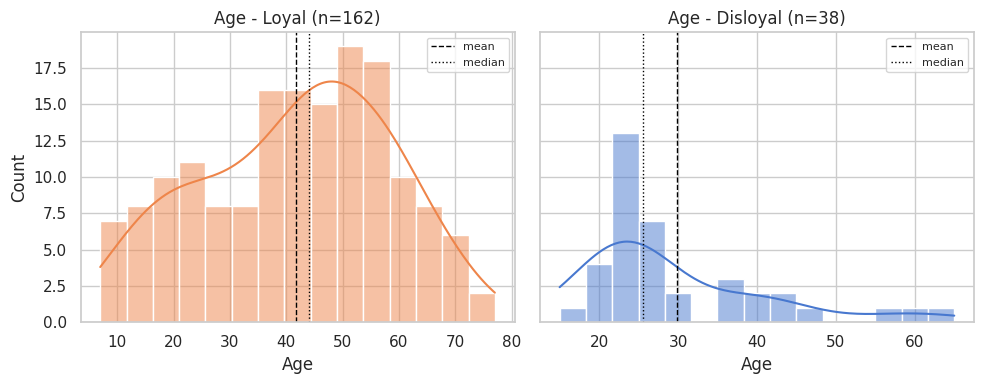

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

sns.histplot(loyal_200, kde=True, ax=axes[0], color='#ee854a', bins=15)
axes[0].set_title(f'Age - Loyal (n={n_loyal})')
axes[0].set_xlabel('Age')
axes[0].axvline(np.mean(loyal_200), color='black', linestyle='--', linewidth=1, label='mean')
axes[0].axvline(np.median(loyal_200), color='black', linestyle=':', linewidth=1, label='median')
axes[0].legend(fontsize=8)

sns.histplot(disloyal_200, kde=True, ax=axes[1], color='#4878cf', bins=15)
axes[1].set_title(f'Age - Disloyal (n={n_disloyal})')
axes[1].set_xlabel('Age')
axes[1].axvline(np.mean(disloyal_200), color='black', linestyle='--', linewidth=1, label='mean')
axes[1].axvline(np.median(disloyal_200), color='black', linestyle=':', linewidth=1, label='median')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### B.3 — Means: estimation, CI, and hypothesis test

Define $\mu_1, \mu_2$ as the population mean Age for Loyal and Disloyal customers respectively, and $\delta = \mu_1 - \mu_2$.

**(a) Estimation and MLE.** We estimate $\mu_1, \mu_2$ by the sample means within each group, and $\delta$ by their difference.

In [11]:
mean_loyal    = loyal_200.mean()
mean_disloyal = disloyal_200.mean()
delta_mean_sample = mean_loyal - mean_disloyal

print(f"Mean Age - Loyal (n={n_loyal}):     {mean_loyal:.3f}")
print(f"Mean Age - Disloyal (n={n_disloyal}): {mean_disloyal:.3f}")
print(f"delta_hat = mu1_hat - mu2_hat = {delta_mean_sample:.3f}")

Mean Age - Loyal (n=162):     41.685
Mean Age - Disloyal (n=38): 29.816
delta_hat = mu1_hat - mu2_hat = 11.869


**Is this the MLE?** Yes. If we assume $\text{Age}\mid Y{=}1 \sim N(\mu_1,\sigma_1^2)$ and $\text{Age}\mid Y{=}0 \sim N(\mu_2,\sigma_2^2)$ independently (a reasonable parametric model for a continuous variable like Age), the log-likelihood factorizes across the two groups, and within each group the MLE of a normal mean is exactly the sample mean. So $\hat\mu_1=\bar{X}_{Loyal}$, $\hat\mu_2=\bar{X}_{Disloyal}$ are MLEs under this model, and $\hat\delta=\hat\mu_1-\hat\mu_2$ is the MLE of $\delta$ by the invariance property of MLEs. (Caveat: this Normal assumption is a simplification — B.6 below shows the Disloyal group in particular is noticeably right-skewed, not perfectly normal. The mean is still a perfectly valid, consistent estimator either way; "Normal" is just the standard model that makes it *also* an MLE.)

**(b) Confidence interval for $\delta$.** Since $\hat\delta$ is (asymptotically) normal by the CLT, we use the same unpooled normal-approximation CI as in Project 2:

$$\hat\delta \;\pm\; z_{1-\alpha/2}\sqrt{\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}}$$

In [12]:
s2_loyal, s2_disloyal = loyal_200.var(ddof=1), disloyal_200.var(ddof=1)
se_delta_mean = np.sqrt(s2_loyal / n_loyal + s2_disloyal / n_disloyal)

ci_mean_lower = delta_mean_sample - Z * se_delta_mean
ci_mean_upper = delta_mean_sample + Z * se_delta_mean

print(f"SE(delta_hat) = {se_delta_mean:.3f}")
print(f"95% CI for delta = mu1 - mu2: [{ci_mean_lower:.3f}, {ci_mean_upper:.3f}]")

SE(delta_hat) = 2.334
95% CI for delta = mu1 - mu2: [7.294, 16.445]


**(c) Estimate on the full population.** We recompute $\delta$ using all 10,000 rows (not just this 200-row sub-sample), and check whether it falls inside the CI from (b).

In [13]:
loyal_pop    = df.loc[df['Customer_Type'] == 1, 'Age']
disloyal_pop = df.loc[df['Customer_Type'] == 0, 'Age']
delta_mean_pop = loyal_pop.mean() - disloyal_pop.mean()

in_ci = ci_mean_lower <= delta_mean_pop <= ci_mean_upper
print(f"delta (full population, n={len(df)}): {delta_mean_pop:.3f}")
print(f"Inside the 200-sample's 95% CI [{ci_mean_lower:.3f}, {ci_mean_upper:.3f}]? {in_ci}")

delta (full population, n=10000): 10.579
Inside the 200-sample's 95% CI [7.294, 16.445]? True


**(d) Testing the hypothesis from B.1** ($H_0: F_{Disloyal}=F_{Loyal}$ vs. $H_1: F_{Disloyal}\prec F_{Loyal}$), with the Wald test and with a permutation test.

*Wald test:* the Wald test needs a single scalar parameter to test, so we translate $H_1$ into its natural parametric form under the Normal model from (a), $H_0:\delta\le 0$ vs. $H_1:\delta>0$ (recall $\delta=\mu_1-\mu_2$, so this says exactly "Loyal customers are not older" vs. "Loyal customers are older"):

$$W = \frac{\hat\delta}{\sqrt{s_1^2/n_1+s_2^2/n_2}}, \qquad \text{reject } H_0 \text{ if } W > z_{1-\alpha}$$

In [14]:
ALPHA_TEST = 0.05
W_stat = delta_mean_sample / se_delta_mean
z_crit_one_sided = stats.norm.ppf(1 - ALPHA_TEST)
p_value_wald = 1 - stats.norm.cdf(W_stat)

print(f"Wald statistic W = {W_stat:.3f}")
print(f"One-sided critical value z_(1-alpha) = {z_crit_one_sided:.3f}")
print(f"Reject H0 (W > z_crit)? {W_stat > z_crit_one_sided}")
print(f"p-value = {p_value_wald:.3e}")

Wald statistic W = 5.084
One-sided critical value z_(1-alpha) = 1.645
Reject H0 (W > z_crit)? True
p-value = 1.844e-07


*Permutation test* (manual — no automatic permutation-test function): this one tests $H_0:F_{Disloyal}=F_{Loyal}$ directly, with no need to translate into $\delta$ first. Under $H_0$ the group labels are exchangeable, so we pool the 200 Age values, repeatedly reshuffle the Loyal/Disloyal labels (keeping the group sizes $n_1=162$, $n_2=38$ fixed), and recompute the mean difference each time as our test statistic. Since $\binom{200}{162}$ is far too large to enumerate exactly, we use random resampling (permitted by the assignment).

In [15]:
# Manual permutation test for the mean difference - no library permutation-test function used.
N_PERM = 10_000
rng_perm = np.random.default_rng(0)
pooled_age = df_test['Age'].values

perm_diffs = np.empty(N_PERM)
for i in range(N_PERM):
    shuffled = rng_perm.permutation(pooled_age)
    perm_diffs[i] = shuffled[:n_loyal].mean() - shuffled[n_loyal:].mean()

p_value_perm_mean = np.mean(perm_diffs >= delta_mean_sample)
print(f"Observed delta_hat = {delta_mean_sample:.3f}")
print(f"Permutation p-value (one-sided, P(perm_diff >= observed)) = {p_value_perm_mean:.4f}")

Observed delta_hat = 11.869
Permutation p-value (one-sided, P(perm_diff >= observed)) = 0.0000


**Interpretation:** In this 200-row sub-sample, Loyal customers are on average **11.9 years older** than Disloyal customers (41.7 vs. 29.8), with a 95% CI of $[7.29, 16.45]$ that comfortably excludes 0. The full-population difference (10.58 years, from all 10,000 rows) falls right inside that CI, so the small sub-sample's estimate is consistent with the true population gap. Both the one-sided Wald test ($W=5.08$, $p\approx 1.8\times10^{-7}$) and the manual permutation test ($p<0.0001$, 0 out of 10,000 reshuffles produced a gap this large) reject $H_0$ decisively and agree with each other — unsurprising given how large this effect is relative to the sample's variability.

### B.4 — Medians: estimation, MLE, bootstrap CI, and hypothesis test

Define $m_1, m_2$ as the population medians (0.5-quantile) of Age for Loyal and Disloyal customers, and $\delta = m_1 - m_2$.

**(a) Estimation and MLE.**

In [16]:
median_loyal    = np.median(loyal_200)
median_disloyal = np.median(disloyal_200)
delta_median_sample = median_loyal - median_disloyal

print(f"Median Age - Loyal (n={n_loyal}):     {median_loyal:.3f}")
print(f"Median Age - Disloyal (n={n_disloyal}): {median_disloyal:.3f}")
print(f"delta_hat = m1_hat - m2_hat = {delta_median_sample:.3f}")

Median Age - Loyal (n=162):     44.000
Median Age - Disloyal (n=38): 25.500
delta_hat = m1_hat - m2_hat = 18.500


**Is this the MLE?** No — not under the *same* model we used in B.3(a). If $\text{Age}\mid Y \sim N(\mu,\sigma^2)$, the MLE is whatever maximizes this normal likelihood, and that maximization is solved specifically by the **sample mean** — the sample median is a different formula (it sorts the data and takes the middle value), so it does not maximize the normal likelihood, even though for a symmetric distribution the population median and population mean are equal. So under the Normal model we're assuming, the sample median is a **valid, consistent, robust estimator** of that same central location — it just isn't the value that maximizes this particular (Normal) likelihood, so it isn't an MLE under our stated model.

**(b) Confidence interval for $\delta$.** Unlike the mean, there is no simple closed-form formula for the standard error of a sample median (its asymptotic variance depends on the unknown probability density *at* the median, which has no simple plug-in estimator). So we build the CI with a **manual, non-parametric bootstrap** (B = 400 replications, no automatic bootstrap function): resample each group separately, with replacement, preserving $n_1=162$ and $n_2=38$, recompute the median difference each time, and take the empirical 2.5%/97.5% percentiles (percentile bootstrap method).

In [17]:
# Manual bootstrap CI for the median difference (stratified: resample within each group).
B_MEDIAN = 400
rng_boot_median = np.random.default_rng(1)

boot_delta_median = np.empty(B_MEDIAN)
for b in range(B_MEDIAN):
    boot_loyal    = rng_boot_median.choice(loyal_200,    size=n_loyal,    replace=True)
    boot_disloyal = rng_boot_median.choice(disloyal_200, size=n_disloyal, replace=True)
    boot_delta_median[b] = np.median(boot_loyal) - np.median(boot_disloyal)

ci_median_lower = np.percentile(boot_delta_median, 2.5)
ci_median_upper = np.percentile(boot_delta_median, 97.5)

print(f"Bootstrap replications: {B_MEDIAN}")
print(f"95% percentile bootstrap CI for delta = m1 - m2: [{ci_median_lower:.3f}, {ci_median_upper:.3f}]")

Bootstrap replications: 400
95% percentile bootstrap CI for delta = m1 - m2: [14.000, 22.500]


**(c) Estimate on the full population**, and check whether it falls inside the CI from (b).

In [18]:
delta_median_pop = loyal_pop.median() - disloyal_pop.median()
in_ci_median = ci_median_lower <= delta_median_pop <= ci_median_upper

print(f"delta (full population, n={len(df)}): {delta_median_pop:.3f}")
print(f"Inside the 200-sample's 95% bootstrap CI [{ci_median_lower:.3f}, {ci_median_upper:.3f}]? {in_ci_median}")

delta (full population, n=10000): 16.000
Inside the 200-sample's 95% bootstrap CI [14.000, 22.500]? True


**(d) Testing the same hypothesis from B.1** ($H_0: F_{Disloyal}=F_{Loyal}$ vs. $H_1: F_{Disloyal}\prec F_{Loyal}$) with a permutation test — identical procedure to B.3(d), just using the **median** difference as the test statistic instead of the mean difference.

In [19]:
N_PERM = 10_000
rng_perm_median = np.random.default_rng(1)

perm_diffs_median = np.empty(N_PERM)
for i in range(N_PERM):
    shuffled = rng_perm_median.permutation(pooled_age)
    perm_diffs_median[i] = np.median(shuffled[:n_loyal]) - np.median(shuffled[n_loyal:])

p_value_perm_median = np.mean(perm_diffs_median >= delta_median_sample)
print(f"Observed delta_hat (median) = {delta_median_sample:.3f}")
print(f"Permutation p-value (one-sided) = {p_value_perm_median:.4f}")

Observed delta_hat (median) = 18.500
Permutation p-value (one-sided) = 0.0002


**(e) Could we use the Wald test or a $t$-test here instead?** Not directly, and this is really the same issue as in (b): both the Wald test and the two-sample $t$-test rely on a simple, known formula for the standard error of the estimator — for the sample **mean**, $\widehat{se} = \sqrt{s_1^2/n_1+s_2^2/n_2}$ falls straight out of the CLT. The sample **median** has no such simple formula: its asymptotic variance is approximately $\frac{1}{4nf(m)^2}$, where $f(m)$ is the (unknown) population density evaluated *at* the median — not something we can estimate from a formula the way we estimate $s^2$. Without a workable $\widehat{se}$, the Wald statistic $\hat\delta/\widehat{se}(\hat\delta)$ simply cannot be computed, and neither can a $t$-statistic (which is the same statistic, calibrated with the $t$ distribution instead of the normal). This is exactly why (b) needed the bootstrap instead of a formula — and it is only *because* we already have the bootstrap distribution of $\hat\delta$ from (b) that a bootstrap-SE-based Wald-type statistic would even be possible; the classical Wald/$t$ test, as originally defined for means, is not.

**Interpretation:** The median gap (18.5 years: 44 vs. 25.5) is even larger than the mean gap from B.3 (11.9 years) — plausible if the Age distribution within one or both groups is skewed rather than perfectly symmetric, so the mean and median tell slightly different (but both valid) stories about the "typical" customer. The bootstrap 95% CI $[14.0, 22.5]$ excludes 0 by a wide margin, the full-population median difference (16.0 years) falls inside it, and the permutation test rejects $H_0$ decisively ($p=0.0002$). All of this points the same direction as B.3: Loyal customers are unambiguously older, whether measured by mean or median.

### B.5 — Rank-sum statistic: permutation test and normal approximation

Define $S_1$ as the sum of ranks of the Loyal group's Age values within the pooled 200-row sample (ranks 1..200, ties broken by the average-rank method). We test the same hypothesis from B.1 ($H_0: F_{Disloyal}=F_{Loyal}$ vs. $H_1: F_{Disloyal}\prec F_{Loyal}$) once more, this time using $S_1$ as the test statistic, with a permutation test — and then check whether the normal approximation is appropriate.

In [20]:
from scipy.stats import rankdata

pooled_ranks = rankdata(df_test['Age'].values, method='average')   # ranks are a fixed function of the pooled data
loyal_mask = (df_test['Customer_Type'].values == 1)
S1_obs = pooled_ranks[loyal_mask].sum()

n_unique = df_test['Age'].nunique()
n_ties = len(df_test) - n_unique
print(f"Unique Age values in the pooled 200-row sample: {n_unique} (out of 200)")
print(f"=> {n_ties} values are involved in ties (Age is reported in whole years, so ties are expected)")
print(f"Observed S1 (sum of ranks, Loyal group): {S1_obs:.1f}")

Unique Age values in the pooled 200-row sample: 63 (out of 200)
=> 137 values are involved in ties (Age is reported in whole years, so ties are expected)
Observed S1 (sum of ranks, Loyal group): 17588.5


**Handling ties.** Since Age is reported in whole years, many observations share the exact same value, and the ranking rule needs to account for this: tied values all receive the **same rank**, equal to the **average** of the ranks they would have occupied had they been slightly different (e.g. two observations tied for ranks 3 and 4 both get rank 3.5; three observations tied for ranks 5, 6, 7 all get rank 6). This is exactly what `rankdata(method='average')` computed above. As a concrete check, here is one tied Age value from our own data and the rank it was assigned:

In [21]:
# Concrete demonstration of the tie-handling rule on our own data
example_age = df_test['Age'].value_counts().idxmax()   # the most frequently repeated Age value
tie_group_size = (df_test['Age'].values == example_age).sum()
example_rank = pooled_ranks[df_test['Age'].values == example_age][0]

print(f"Age = {example_age} appears {tie_group_size} times in the pooled 200-row sample.")
print(f"All {tie_group_size} of these tied observations share the averaged rank: {example_rank}")

Age = 22 appears 8 times in the pooled 200-row sample.
All 8 of these tied observations share the averaged rank: 35.5


**Permutation test.** Since $S_1$ depends only on the (fixed) ranks of the pooled data, "permuting the data" is equivalent to permuting the rank labels: repeatedly reshuffle which 162 of the 200 fixed ranks are called "Loyal", and sum them.

In [22]:
rng_perm_rank = np.random.default_rng(2)
perm_S1 = np.empty(N_PERM)
for i in range(N_PERM):
    shuffled_ranks = rng_perm_rank.permutation(pooled_ranks)
    perm_S1[i] = shuffled_ranks[:n_loyal].sum()

p_value_perm_rank = np.mean(perm_S1 >= S1_obs)
print(f"Permutation p-value (one-sided, P(perm S1 >= observed)) = {p_value_perm_rank:.4f}")

Permutation p-value (one-sided, P(perm S1 >= observed)) = 0.0000


**Normal approximation.** Assuming no ties, $E[S_1] = \frac{n_1(N+1)}{2}$ and $\text{Var}(S_1) = \frac{n_1 n_2 (N+1)}{12}$, giving the test statistic $T = (S_1 - E[S_1])/\sqrt{\text{Var}(S_1)}$, rejecting for large $T$. The usual rule of thumb is that both group sizes should be at least around 30 for the normal approximation to be trustworthy; here $n_1=162$ is comfortably large and $n_2=38$ clears that bar, if only just — so the approximation should be usable, but is less comfortably justified for the smaller (Disloyal) group than for the larger one. Separately, note the caveat above: this formula strictly assumes **no ties**, and we do have some ties in Age (a whole-number variable), so treat this p-value as an approximation rather than an exact result.

In [23]:
N_total = n_loyal + n_disloyal
E_S1 = n_loyal * (N_total + 1) / 2
Var_S1 = n_loyal * n_disloyal * (N_total + 1) / 12

T_stat = (S1_obs - E_S1) / np.sqrt(Var_S1)
p_value_normal_rank = 1 - stats.norm.cdf(T_stat)

print(f"E[S1] = {E_S1:.2f},  Var(S1) = {Var_S1:.2f}")
print(f"T statistic = {T_stat:.3f}")
print(f"Normal-approximation p-value = {p_value_normal_rank:.3e}")
print(f"Permutation-based p-value    = {p_value_perm_rank:.4f}")

E[S1] = 16281.00,  Var(S1) = 103113.00
T statistic = 4.072
Normal-approximation p-value = 2.333e-05
Permutation-based p-value    = 0.0000


**Interpretation:** There actually are meaningful ties here — only 63 unique Age values out of 200 rows, since Age is reported in whole years. Despite that, the normal approximation ($p \approx 2.3\times10^{-5}$) and the permutation test ($p<0.0001$) agree closely and both reject $H_0$ decisively. This makes sense: the tie-correction to the exact variance formula shrinks $\text{Var}(S_1)$ slightly, but with an effect this large (Loyal customers' ranks are, on average, far higher than Disloyal customers') even a mildly imprecise variance estimate is nowhere near enough to change the conclusion.

### B.6 — Do these results match the histograms?

Project 1/2 described both groups' Age distributions as "approximately bell-shaped" — and the histograms plotted above in B.2 (for this specific 200-row sample) largely support that. We check this more precisely by comparing each group's mean, median, and skewness directly.

In [24]:
for name, g in [('Loyal', loyal_200), ('Disloyal', disloyal_200)]:
    print(f"{name:9s}: n={len(g):3d}  mean={g.mean():6.2f}  median={np.median(g):6.2f}  skewness={stats.skew(g):+.3f}")

Loyal    : n=162  mean= 41.69  median= 44.00  skewness=-0.211
Disloyal : n= 38  mean= 29.82  median= 25.50  skewness=+1.438


**Discussion.** All three approaches in B.3–B.5 (mean, median, rank-sum) agree emphatically: Loyal customers are older than Disloyal customers, with every test rejecting $H_0$ at a tiny p-value. That much is fully consistent with the clearly-separated histograms from Project 1/2.

But there is a real nuance the histograms undersell: the **median-based gap (18.5 years) is noticeably larger than the mean-based gap (11.9 years)**. This isn't a contradiction — it's explained by the skewness numbers above. The Loyal group is close to symmetric (skewness $\approx -0.21$), so its mean and median are close (41.7 vs. 44.0). The Disloyal group, however, is **meaningfully right-skewed** (skewness $\approx +1.44$: mean 29.8 sits noticeably *above* its own median of 25.5), which makes sense given its small size ($n=38$) — a handful of older Disloyal customers in the tail pull the mean upward without moving the median. So "approximately bell-shaped" was a reasonable first-pass description for the pooled/overall histograms, but the Disloyal sub-group specifically is more right-skewed than that description suggests, and that skew is exactly why the mean and median tests here (both correctly) report somewhat different-sized effects for the same underlying pattern.